In [ ]:
 library(readxl)
install.packages("randomForest")
  install.packages("e1071")
library(e1071)
library(randomForest)
library(rpart)
install.packages("rpart.plot") #install the package for the rpart.plot function
library(rpart.plot)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
 data <- read_excel("/content/Total annual litterfall SI.xlsx")
 summary(data)
 data<-data[-c(1,19)]
head(data)

       ID             site          Latitude       Longitude     
 Min.   :  1.0   Min.   :  1.0   Min.   :18.26   Min.   : 82.25  
 1st Qu.:244.2   1st Qu.: 75.0   1st Qu.:24.28   1st Qu.:108.35  
 Median :485.5   Median :148.0   Median :27.05   Median :112.92  
 Mean   :485.1   Mean   :150.7   Mean   :30.35   Mean   :114.07  
 3rd Qu.:726.8   3rd Qu.:222.0   3rd Qu.:32.98   3rd Qu.:118.38  
 Max.   :968.0   Max.   :314.0   Max.   :51.50   Max.   :129.53  
  Altitude(m)          MAT            MAP(mm)      Age(year)        
 Min.   :   0.0   Min.   :-5.400   Min.   : 370   Length:966        
 1st Qu.: 200.0   1st Qu.: 8.625   1st Qu.: 870   Class :character  
 Median : 373.0   Median :16.800   Median :1400   Mode  :character  
 Mean   : 701.6   Mean   :13.958   Mean   :1335                     
 3rd Qu.: 783.0   3rd Qu.:19.500   3rd Qu.:1727                     
 Max.   :4115.0   Max.   :25.400   Max.   :2800                     
   DBH(cm)           Height(m)         Density(trees pe

site,Latitude,Longitude,Altitude(m),MAT,MAP(mm),Age(year),DBH(cm),Height(m),Density(trees per ha),Leaf(Mg per ha per yr),Branch(Mg per ha per yr),Reproduction and Others(Mg per ha per yr),Total(Mg per ha per yr),Forest type,Measurement interval,Trap size(mm),Stand origin
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,31.69,103.90,1830,8.9,945,23.0,8.7,6.4,3900.0,NA,NA,NA,5.9000,Needleleaf forest,2002.09-2003.08,1.0,Planted
2,26.80,117.98,230,19.5,1653,6.0,9.7,6.3,1933.0,0.1883,0.0452,0.5,0.2677,Needleleaf forest,2002.0,0.5,Planted
2,26.80,117.98,230,19.5,1653,7.0,11.0,7.4,1933.0,0.2384,0.0267,0.5,0.3015,Needleleaf forest,2003.0,0.5,Planted
2,26.80,117.98,230,19.5,1653,8.0,12.3,8.3,1931.0,0.2996,0.0344,0.5,0.3699,Needleleaf forest,2004.0,0.5,Planted
2,26.80,117.98,230,19.5,1653,9.0,13.5,9.1,1927.0,0.3125,0.0416,0.5,0.4004,Needleleaf forest,2005.0,0.5,Planted
3,38.48,100.20,2780,0.5,441,168.0,22.6,19.8,940.0,1.3107,0.5228,1,2.1656,Needleleaf forest,NA,1.0,Primary


In [ ]:
print("number of duplicated rows:")
print(sum(duplicated(data)))

[1] "number of duplicated rows:"
[1] 0


In [ ]:
numeric_columns <- c("site","Latitude", "Longitude", "Altitude(m)", "MAT", "MAP(mm)", "Age(year)", "DBH(cm)", "Height(m)", "Density(trees per ha)", "Leaf(Mg per ha per yr)", "Branch(Mg per ha per yr)", "Reproduction and Others(Mg per ha per yr)", "Total(Mg per ha per yr)","Measurement interval","Trap size(mm)")

In [ ]:
data$`Forest type`[data$`Forest type`=="Needleleaf forest"]<-1
data$`Forest type`[data$`Forest type`== "Broadleaf forest"]<-2
data$`Forest type`[data$`Forest type`=="Mixed forest"]<-3
data$`Forest type`<-as.integer(data$`Forest type`)   # convert tybe to intger

data$`Stand origin`[data$`Stand origin`=="Planted"]<-1
data$`Stand origin`[data$`Stand origin`=="Natural"]<-2
data$`Stand origin`[data$`Stand origin`=="Secondary"]<-3
data$`Stand origin`[data$`Stand origin`=="Primary"]<-4
data$`Stand origin`<-as.integer(data$`Stand origin`)  # convert tybe to intger

head(data)

site,Latitude,Longitude,Altitude(m),MAT,MAP(mm),Age(year),DBH(cm),Height(m),Density(trees per ha),Leaf(Mg per ha per yr),Branch(Mg per ha per yr),Reproduction and Others(Mg per ha per yr),Total(Mg per ha per yr),Forest type,Measurement interval,Trap size(mm),Stand origin
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<chr>,<int>
1,31.69,103.90,1830,8.9,945,23.0,8.7,6.4,3900.0,NA,NA,NA,5.9000,1,2002.09-2003.08,1.0,1
2,26.80,117.98,230,19.5,1653,6.0,9.7,6.3,1933.0,0.1883,0.0452,0.5,0.2677,1,2002.0,0.5,1
2,26.80,117.98,230,19.5,1653,7.0,11.0,7.4,1933.0,0.2384,0.0267,0.5,0.3015,1,2003.0,0.5,1
2,26.80,117.98,230,19.5,1653,8.0,12.3,8.3,1931.0,0.2996,0.0344,0.5,0.3699,1,2004.0,0.5,1
2,26.80,117.98,230,19.5,1653,9.0,13.5,9.1,1927.0,0.3125,0.0416,0.5,0.4004,1,2005.0,0.5,1
3,38.48,100.20,2780,0.5,441,168.0,22.6,19.8,940.0,1.3107,0.5228,1,2.1656,1,NA,1.0,4


Warning message:
“NAs introduced by coercion”
Warning message:
“NAs introduced by coercion”
Warning message:
“NAs introduced by coercion”
Warning message:
“NAs introduced by coercion”
Warning message:
“NAs introduced by coercion”
Warning message:
“NAs introduced by coercion”
Warning message:
“NAs introduced by coercion”
Warning message:
“NAs introduced by coercion”
Warning message:
“NAs introduced by coercion”


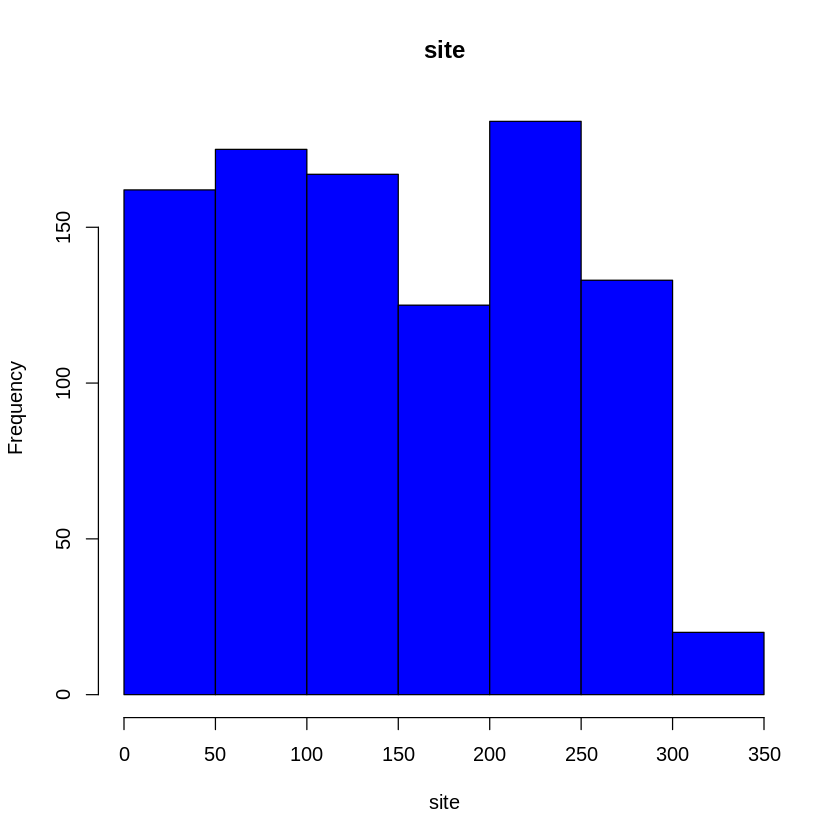

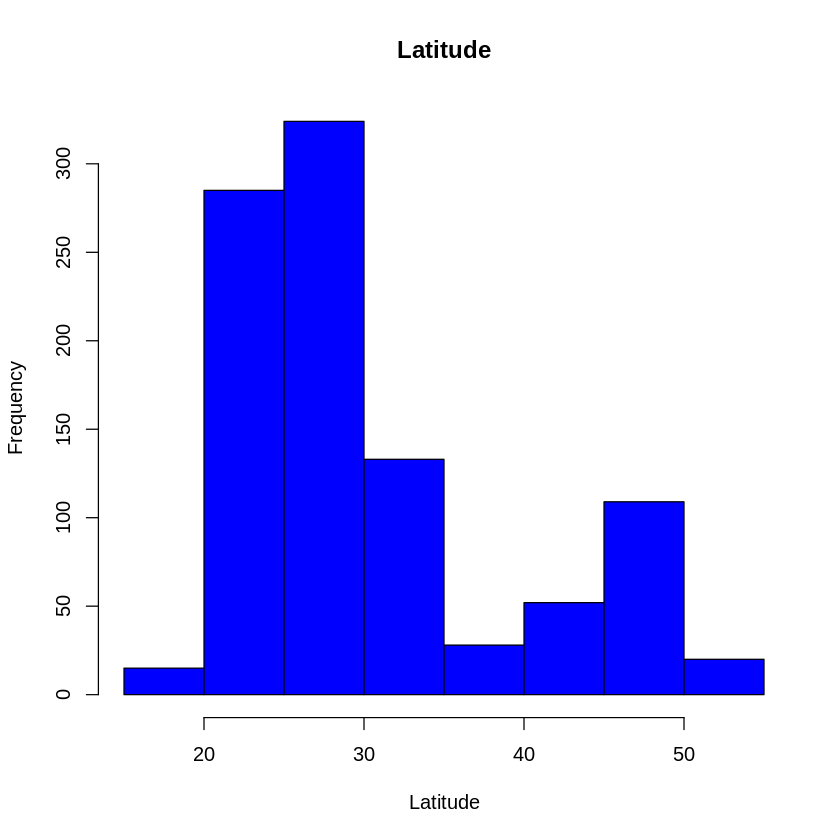

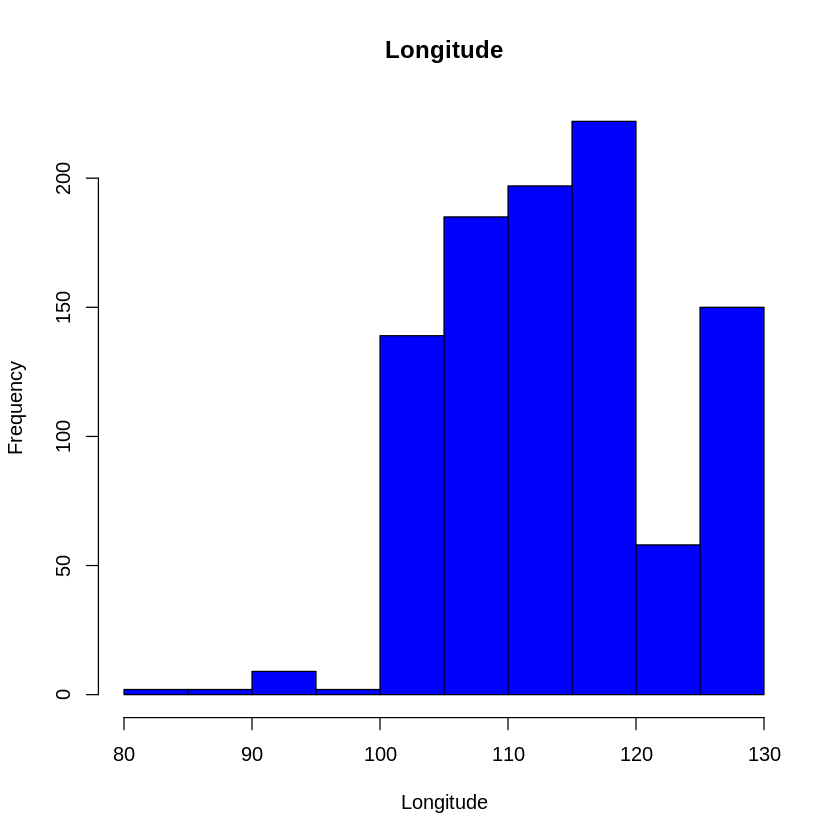

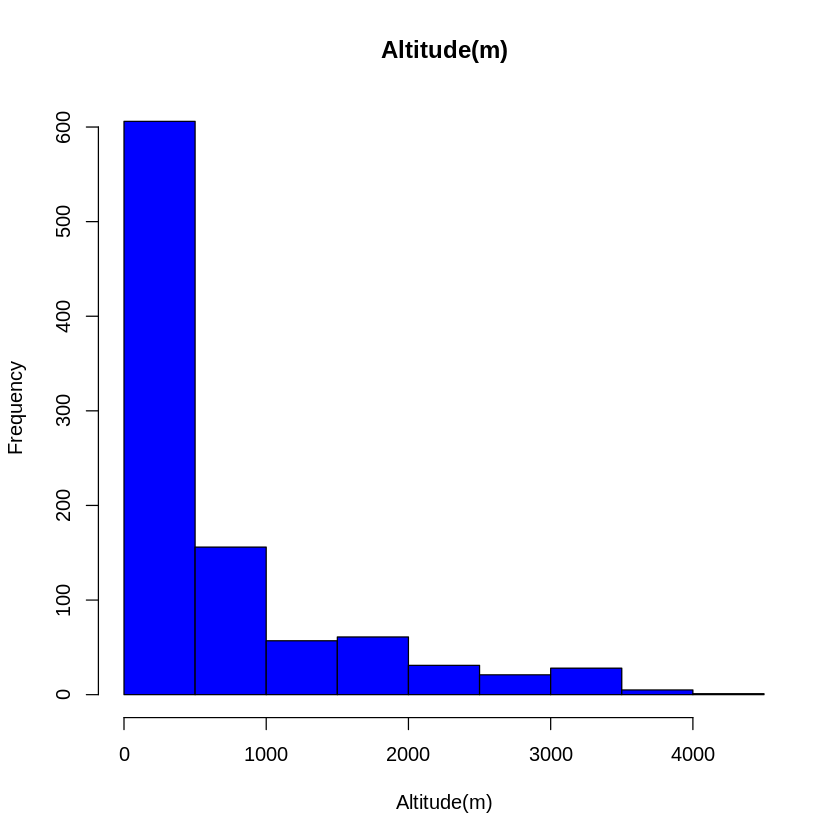

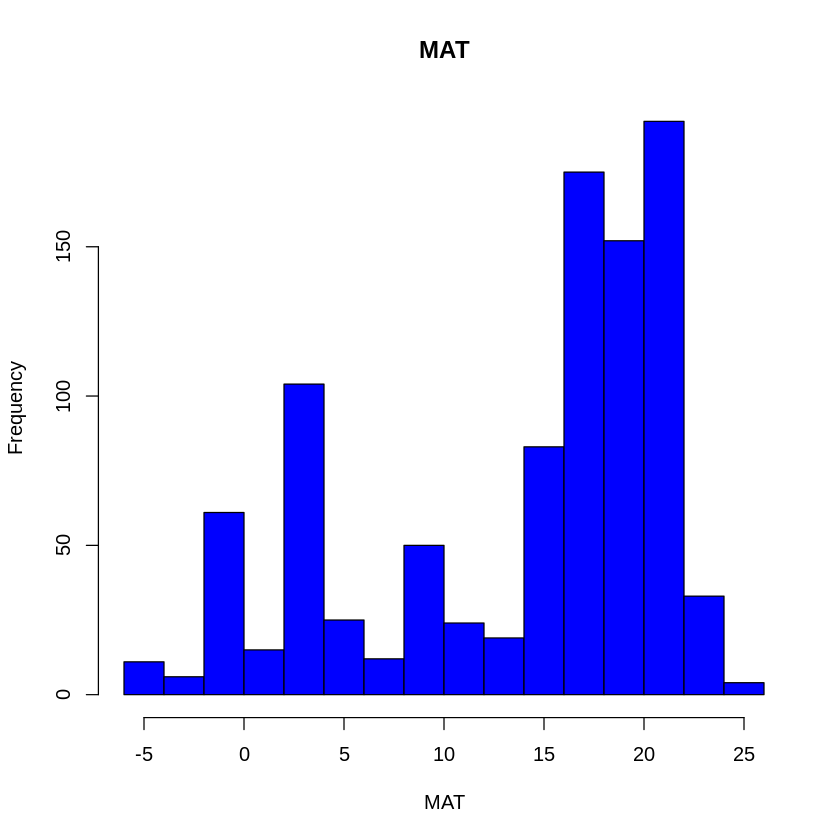

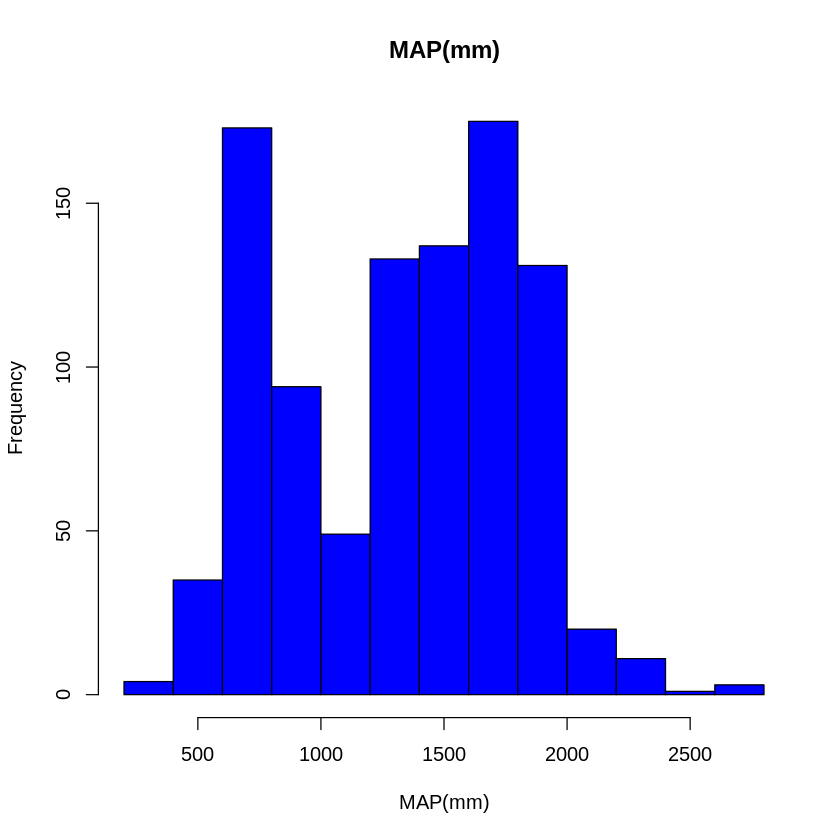

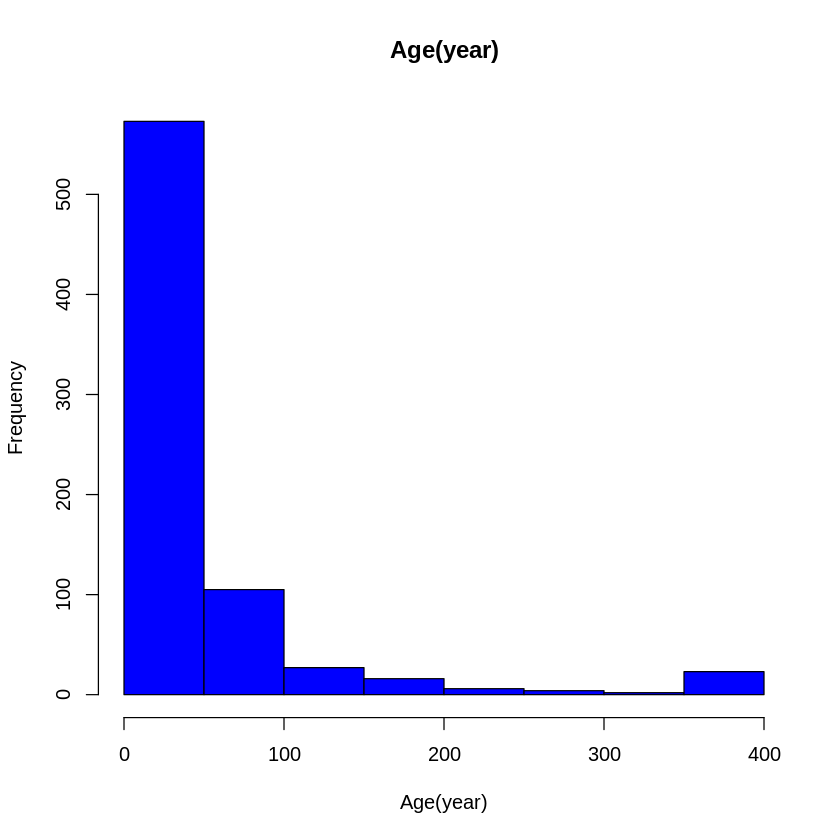

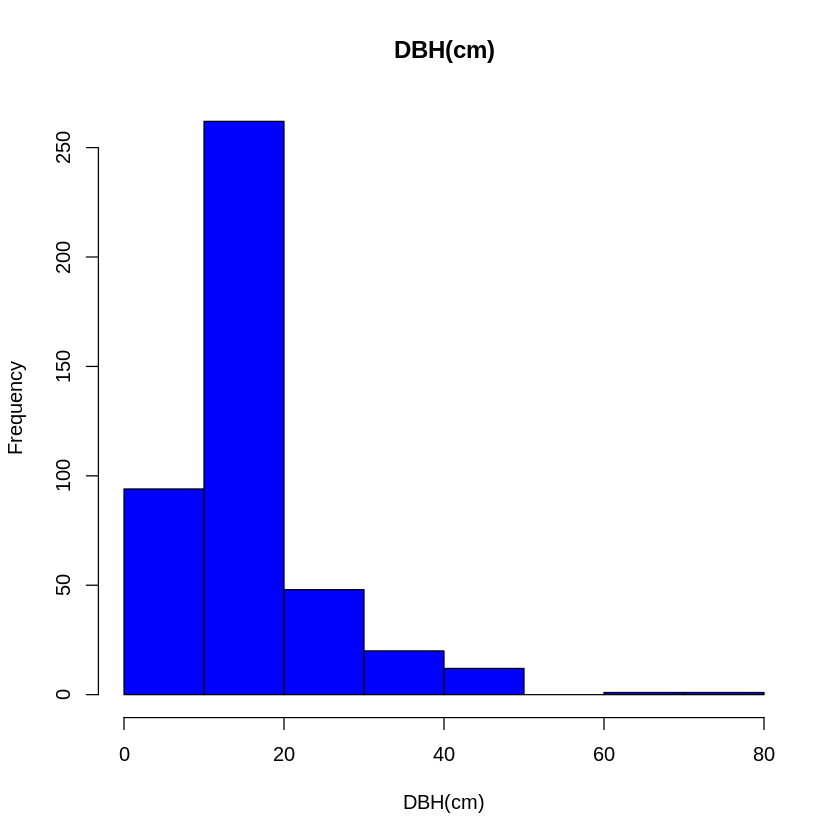

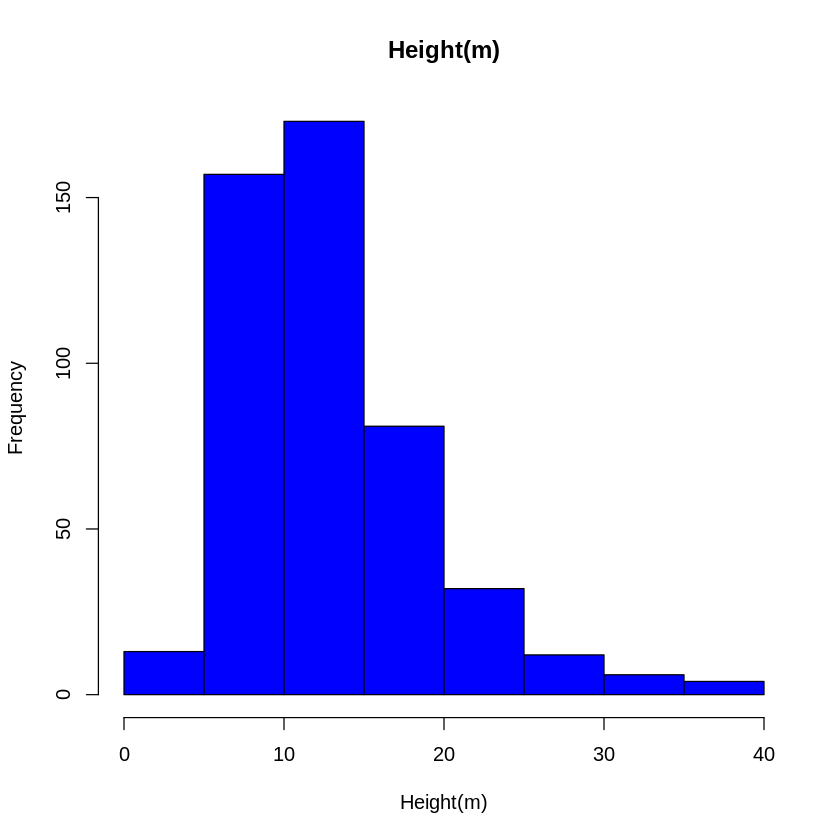

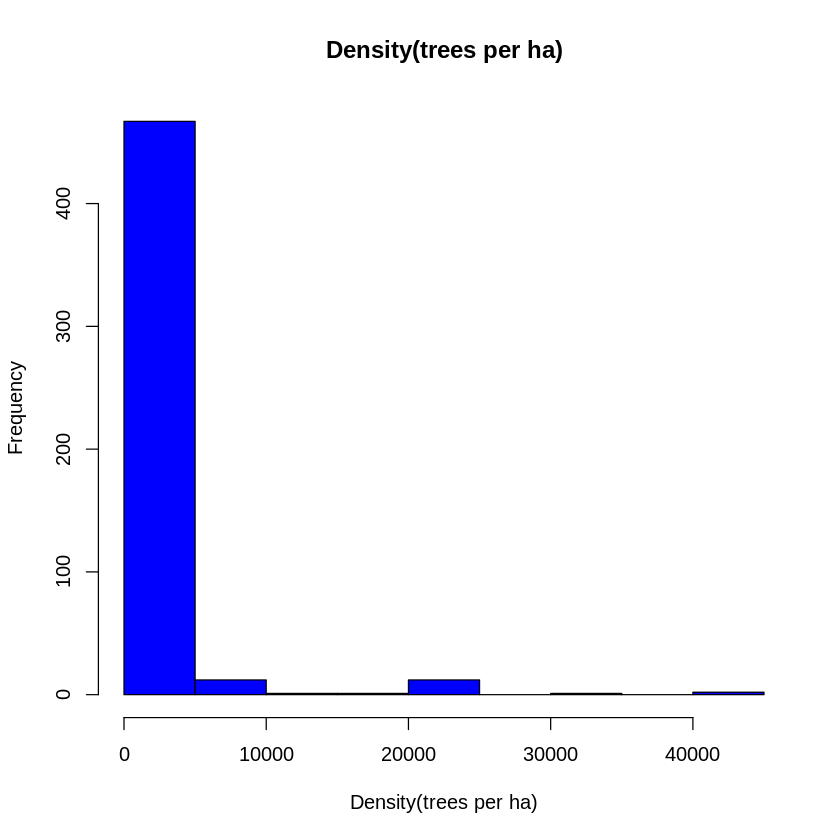

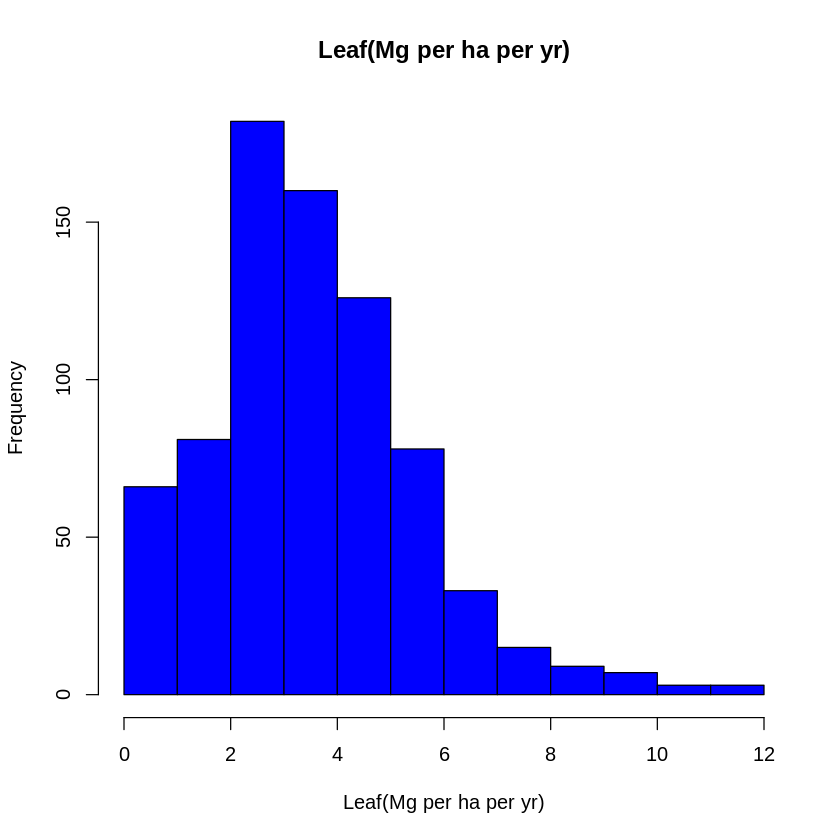

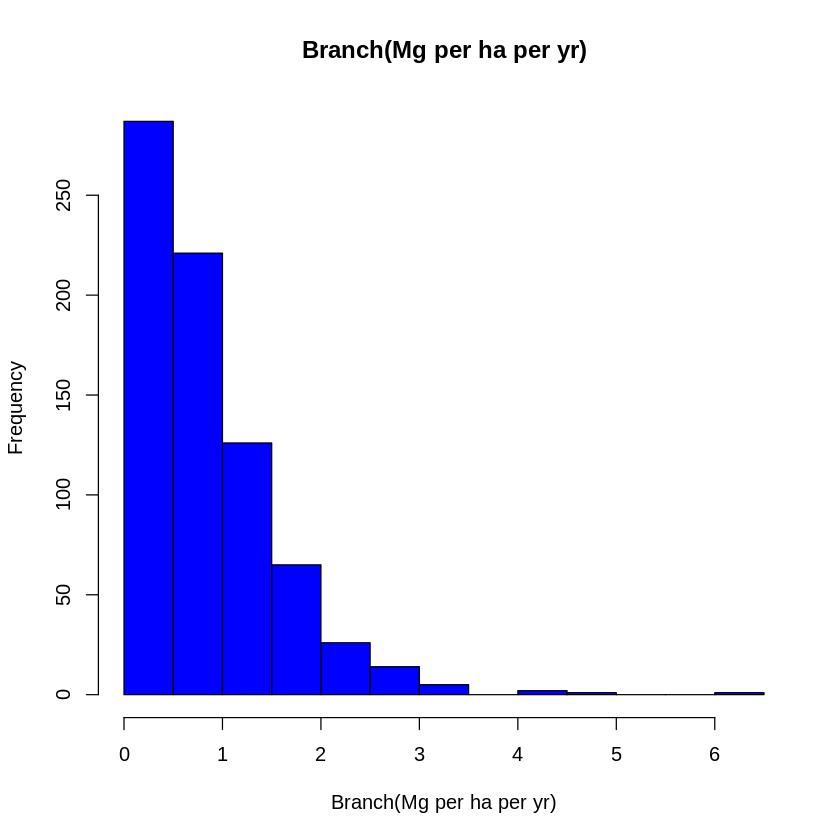

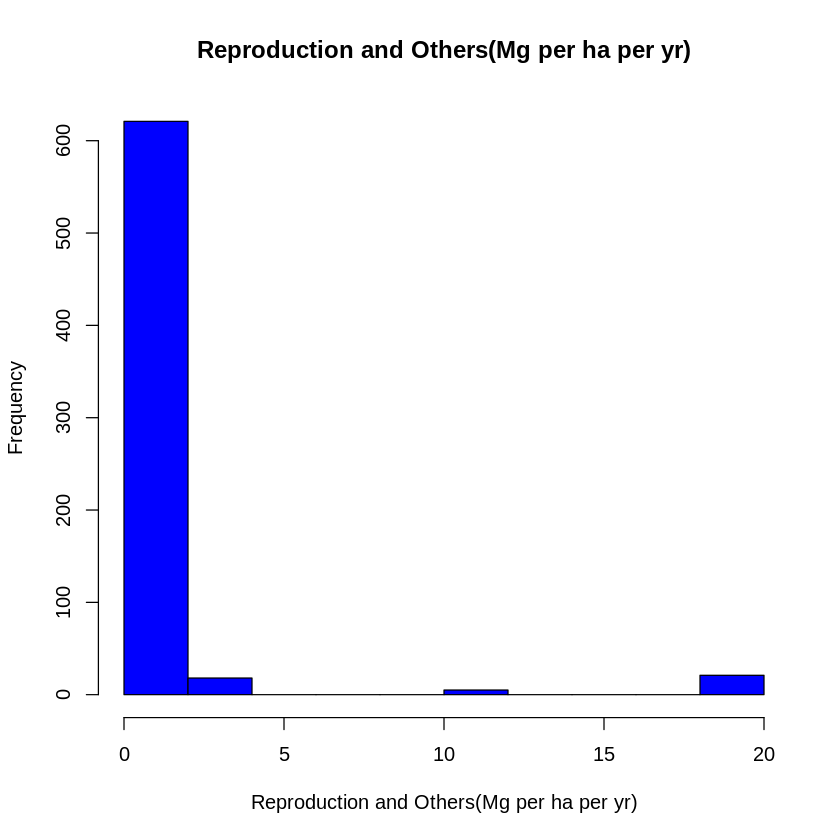

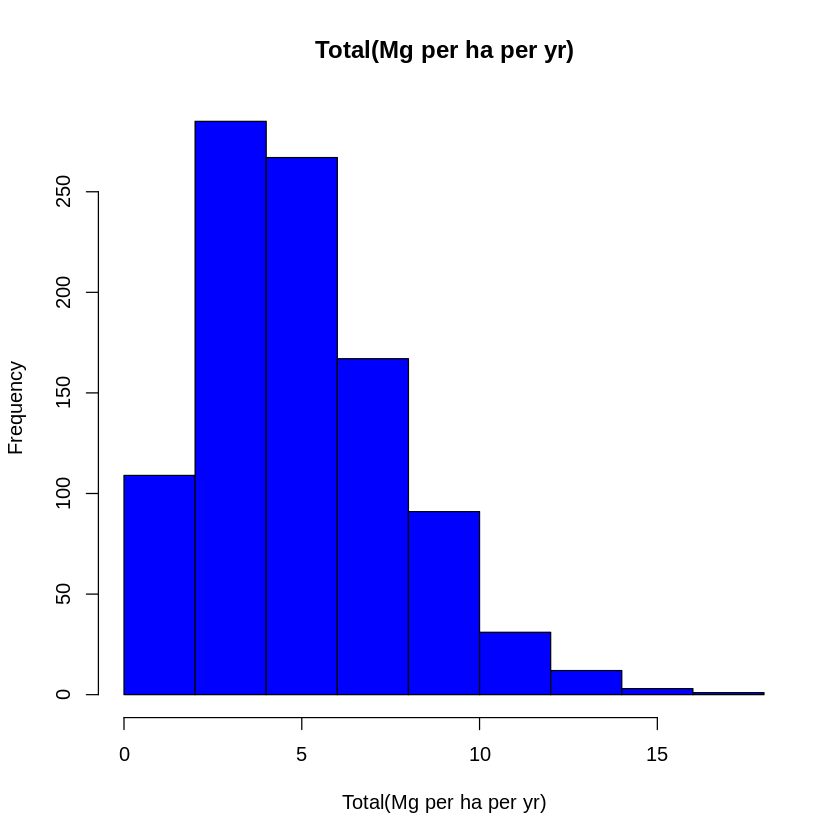

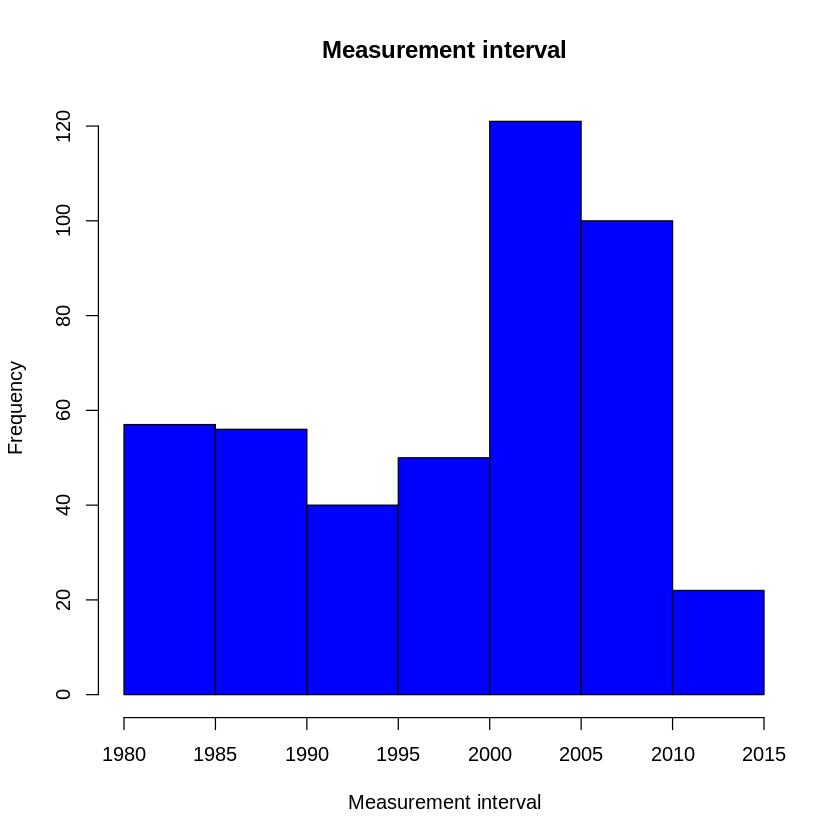

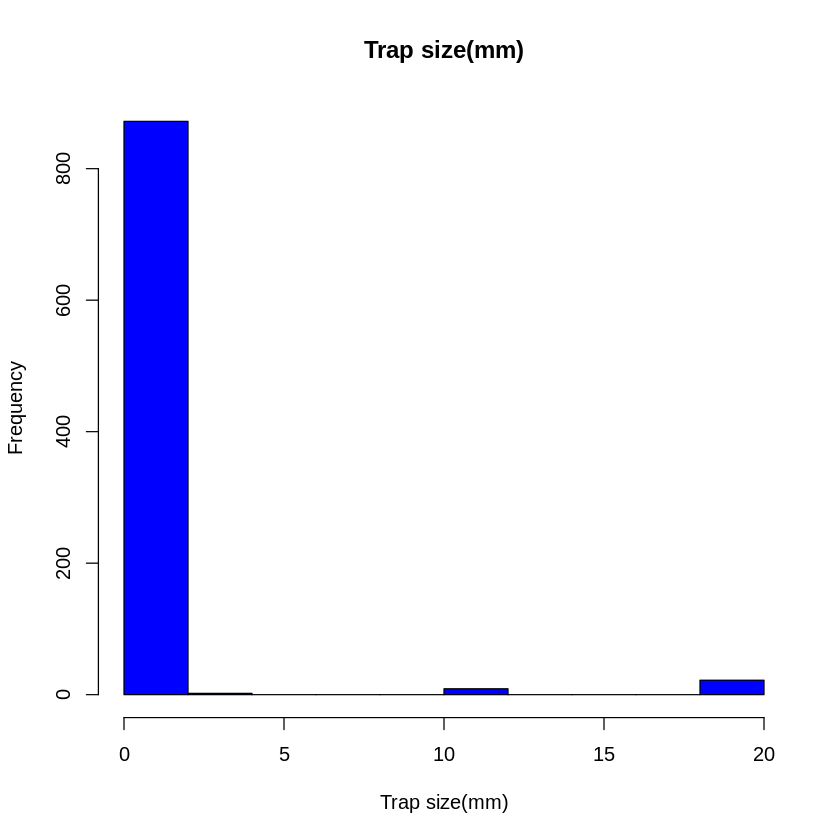

In [ ]:
for (col in numeric_columns) {
  data[[col]] <- as.numeric(as.character(data[[col]]))  # Coerce to numeric
}

for (col in numeric_columns) {
  hist(data[[col]], main = col, xlab = col, col = "blue")
}


In [ ]:
data$`Measurement interval` <- sapply(data$`Measurement interval`, function(x) {
  if (grepl("-", x)) {
    # Extract part before the '-' using strsplit
    strsplit(x, "-")[[1]][1]
  } else {
    # Keep the value unchanged
    x
  }
})


In [ ]:
remove_outliers <- function(x, na.rm = TRUE) {
  if (!is.numeric(x)) return(x)  # Ensure only numeric data is processed
  q1 <- quantile(x, 0.25, na.rm = na.rm)
  q3 <- quantile(x, 0.75, na.rm = na.rm)
  iqr <- q3 - q1  # Interquartile Range
  lower <- q1 - 1.5 * iqr
  upper <- q3 + 1.5 * iqr
  x[x < lower | x > upper] <- NA  # Replace outliers with NA
  return(x)
}

In [ ]:
num_na <- sum(is.na(data[numeric_columns]))
print(num_na)

[1] 2999


In [ ]:
for (col in numeric_columns) {
  data[[col]][is.na(data[[col]])] <- mean(data[[col]], na.rm = TRUE)
}

num_na <- sum(is.na(data[numeric_columns]))
print(num_na)

[1] 0


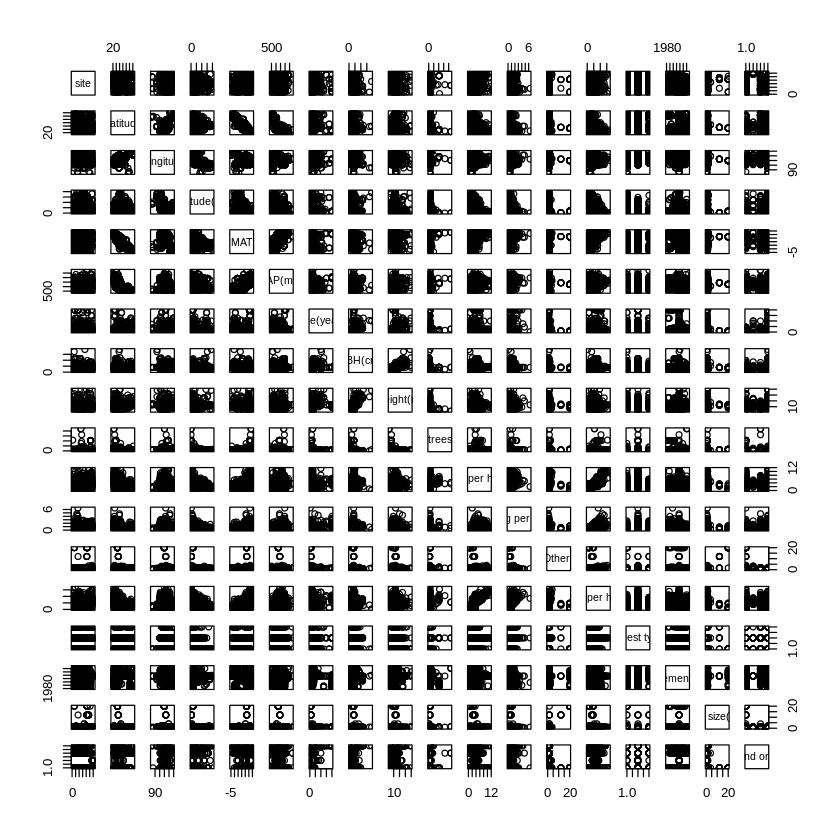

In [ ]:
plot(data)

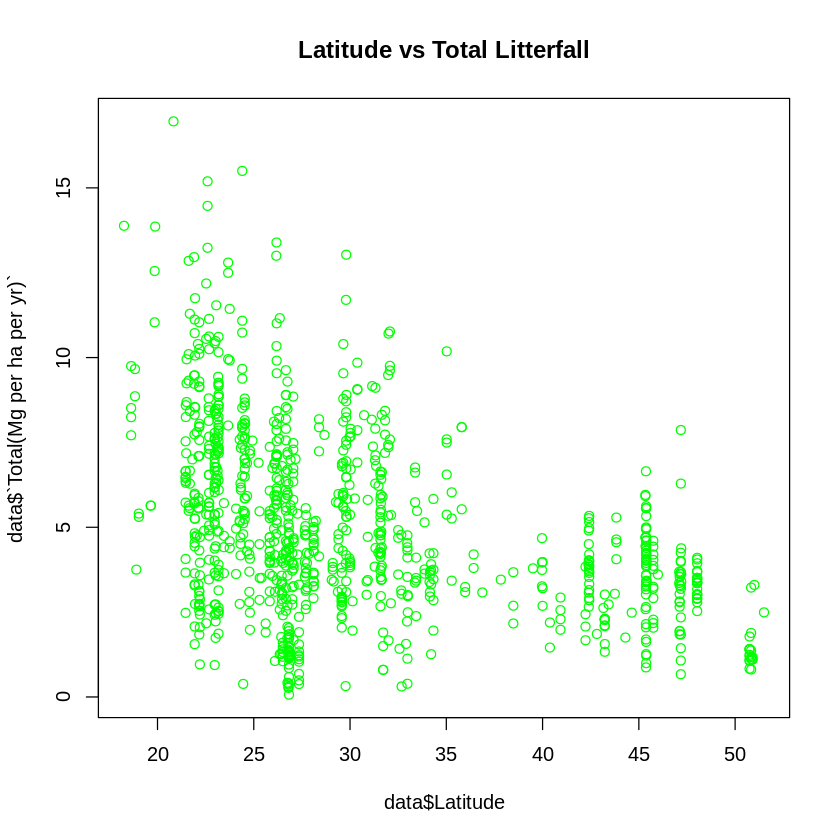

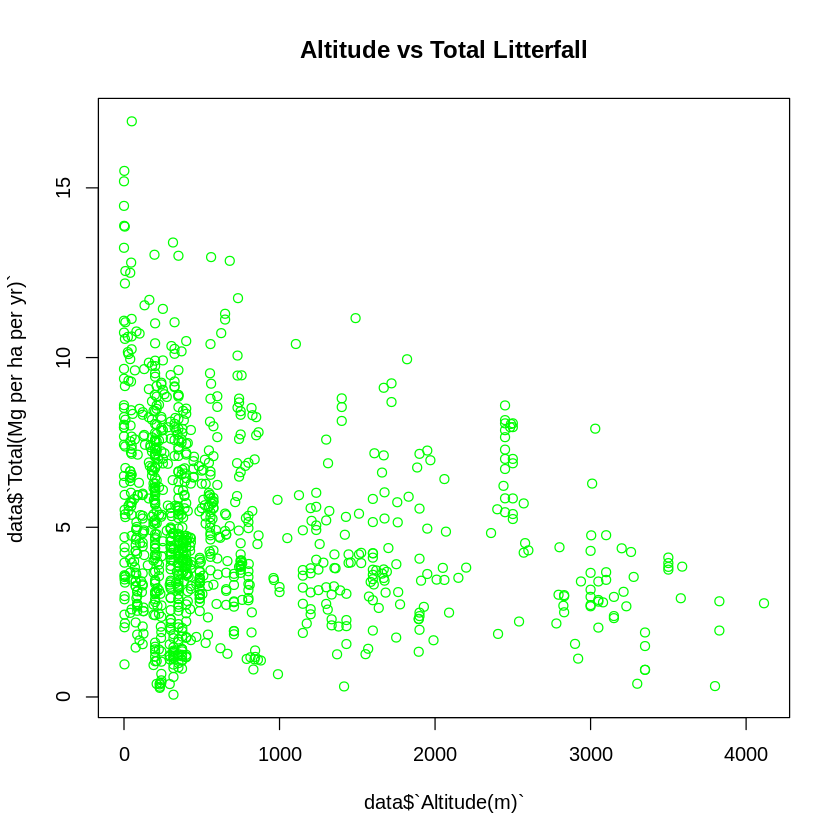

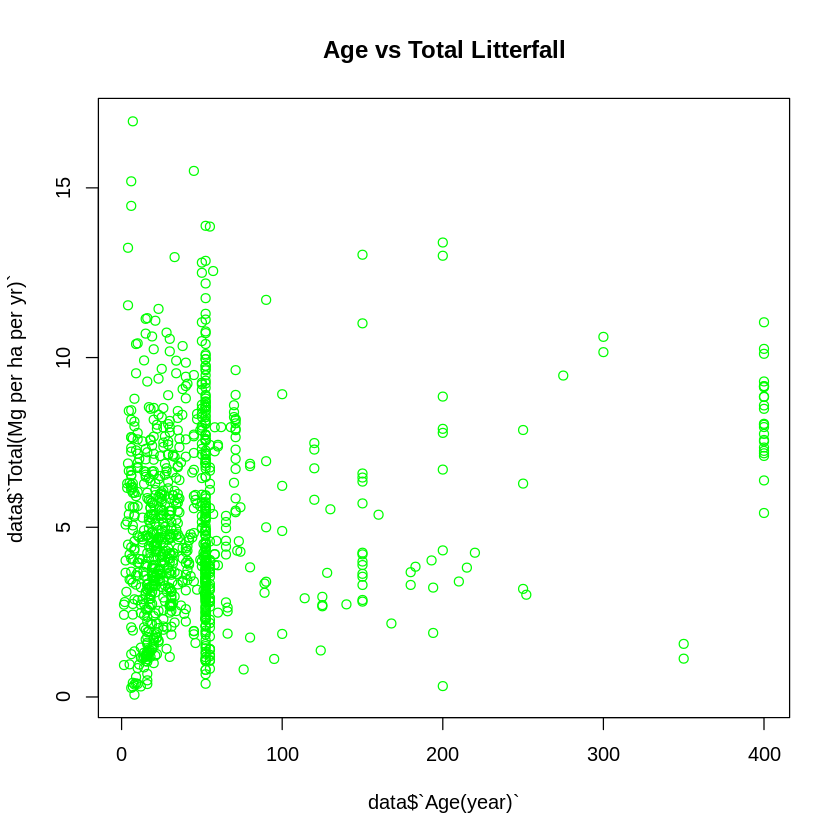

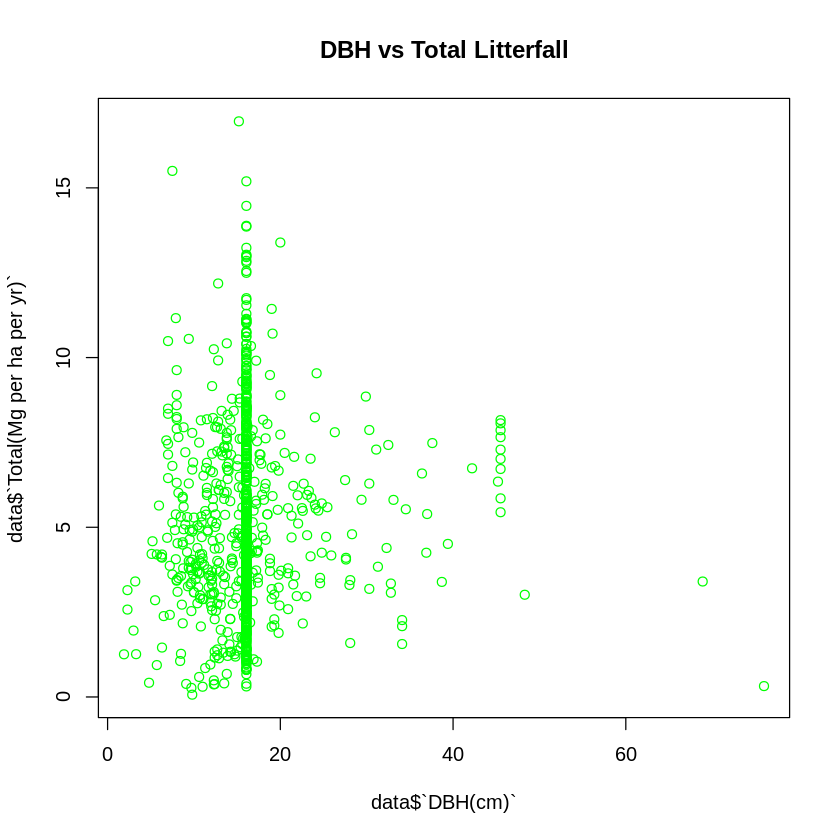

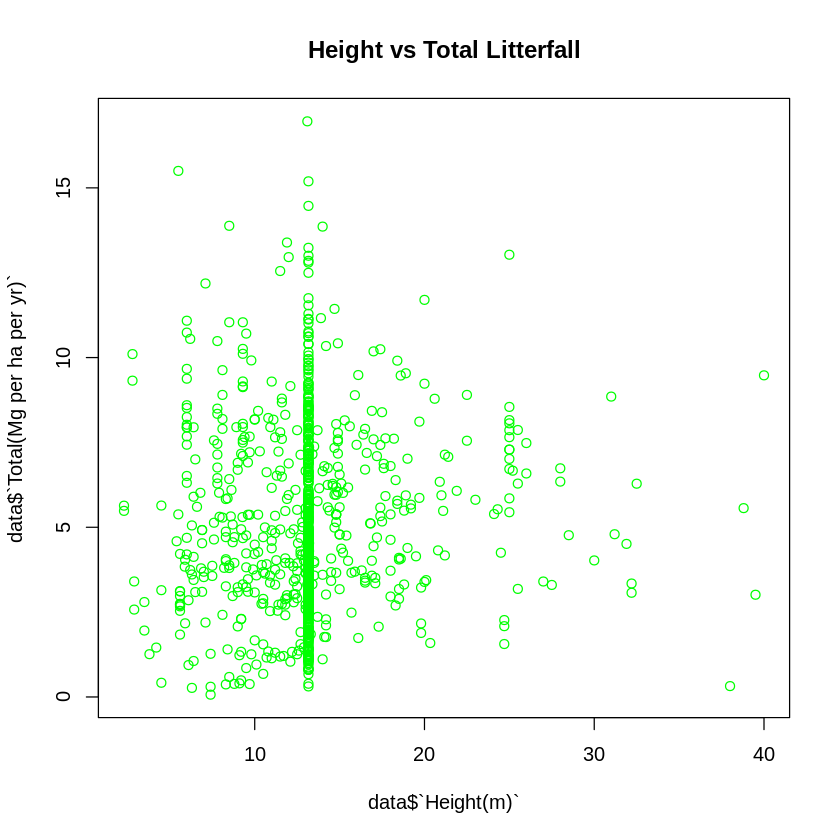

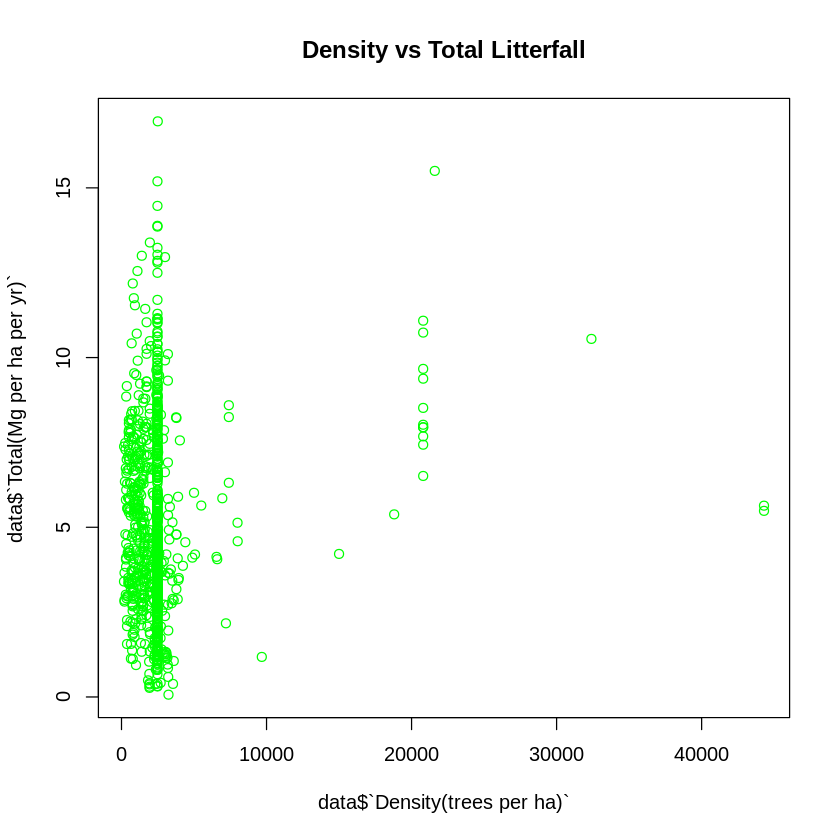

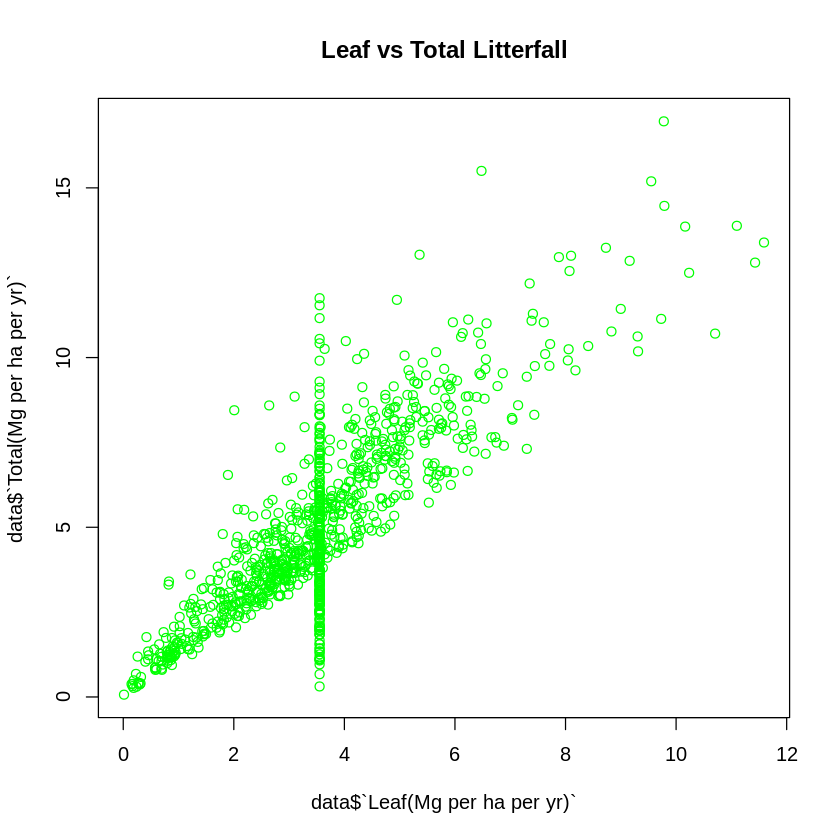

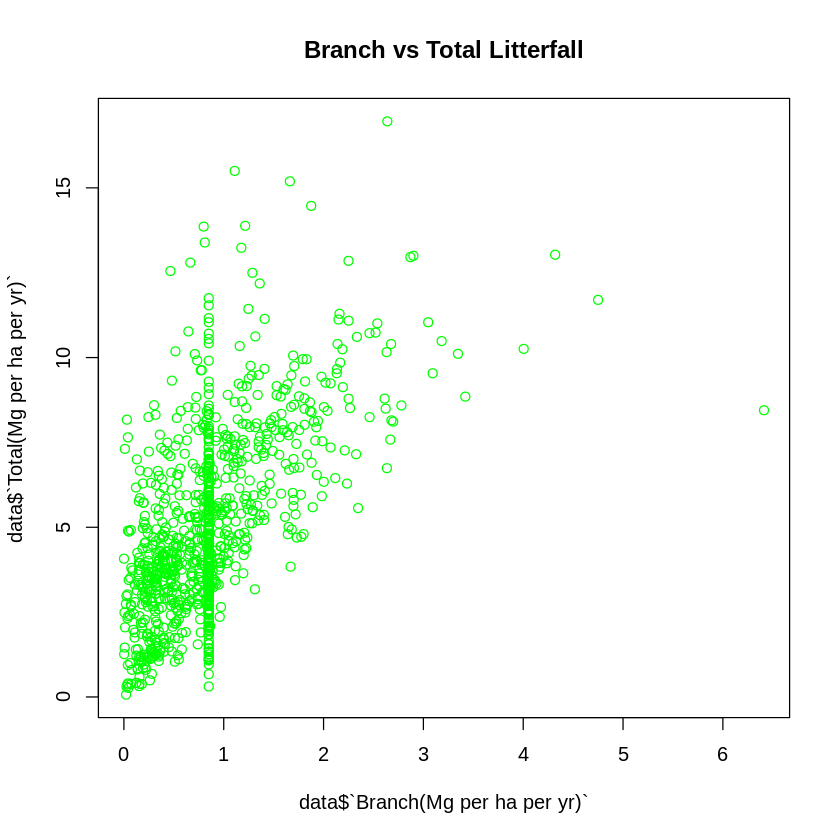

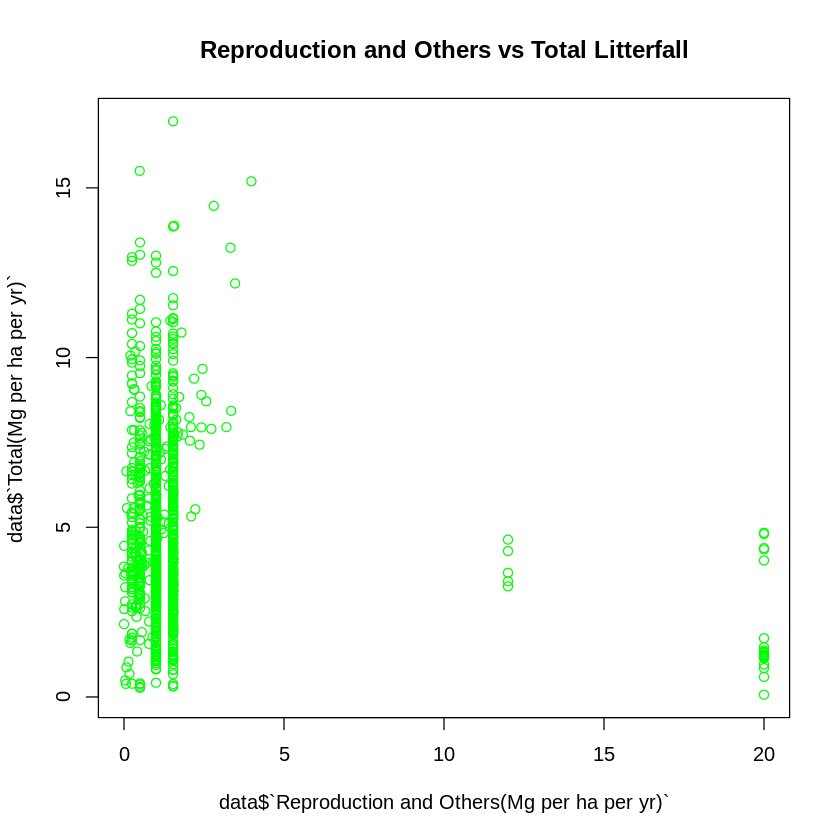

In [ ]:
plot(data$Latitude, data$`Total(Mg per ha per yr)`, col = "green", main = "Latitude vs Total Litterfall")
plot(data$`Altitude(m)`, data$`Total(Mg per ha per yr)`, col = "green", main = "Altitude vs Total Litterfall")
plot(data$`Age(year)`, data$`Total(Mg per ha per yr)`, col = "green", main = "Age vs Total Litterfall")
plot(data$`DBH(cm)`, data$`Total(Mg per ha per yr)`, col = "green", main = "DBH vs Total Litterfall")
plot(data$`Height(m)`, data$`Total(Mg per ha per yr)`, col = "green", main = "Height vs Total Litterfall")
plot(data$`Density(trees per ha)`, data$`Total(Mg per ha per yr)`, col = "green", main = "Density vs Total Litterfall")
plot(data$`Leaf(Mg per ha per yr)`, data$`Total(Mg per ha per yr)`, col = "green", main = "Leaf vs Total Litterfall")
plot(data$`Branch(Mg per ha per yr)`, data$`Total(Mg per ha per yr)`, col = "green", main = "Branch vs Total Litterfall")
plot(data$`Reproduction and Others(Mg per ha per yr)`, data$`Total(Mg per ha per yr)`, col = "green", main = "Reproduction and Others vs Total Litterfall")

[1] "Correlation with 'Total(Mg per ha per yr)':"
                                                                           Variable
site                                                                           site
Latitude                                                                   Latitude
Longitude                                                                 Longitude
Altitude(m)                                                             Altitude(m)
MAT                                                                             MAT
MAP(mm)                                                                     MAP(mm)
Age(year)                                                                 Age(year)
DBH(cm)                                                                     DBH(cm)
Height(m)                                                                 Height(m)
Density(trees per ha)                                         Density(trees per ha)
Leaf(Mg per ha per yr)    

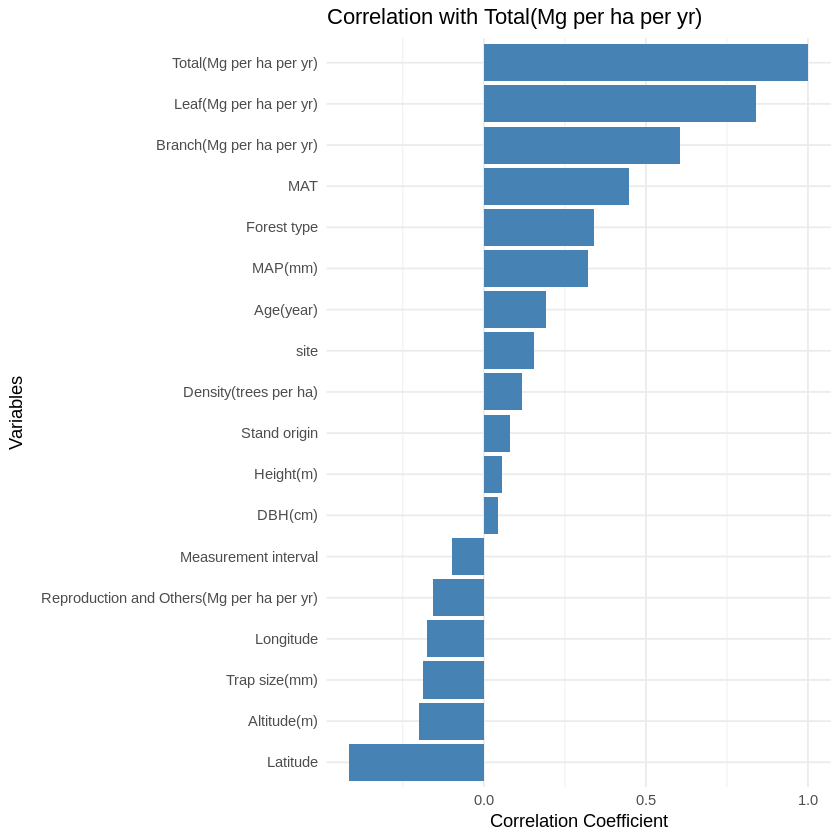

In [ ]:
#Select numeric columns
numeric_cols <- sapply(data, is.numeric)
numeric_data <- data[, numeric_cols]

#Calculate correlation
cor_with_total <- cor(numeric_data, data[["Total(Mg per ha per yr)"]], use = "pairwise.complete.obs")

#Ensure cor_with_total is valid
if (is.null(cor_with_total) || length(cor_with_total) == 0) {
  stop("Correlation calculation failed. Check if 'Total(Mg per ha per yr)' exists and is numeric.")
}

#Create a data frame for visualization
cor_with_total_df <- data.frame(Variable = colnames(numeric_data), Correlation = cor_with_total)
print("Correlation with 'Total(Mg per ha per yr)':")
print(cor_with_total_df)


#Visualization
library(ggplot2)
ggplot(cor_with_total_df, aes(x = reorder(Variable, Correlation), y = Correlation)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  coord_flip() +
  labs(title = "Correlation with Total(Mg per ha per yr)", x = "Variables", y = "Correlation Coefficient") +
  theme_minimal()


In [ ]:
data <- data[-c(8,9,16)]
head(data)

site,Latitude,Longitude,Altitude(m),MAT,MAP(mm),Age(year),Density(trees per ha),Leaf(Mg per ha per yr),Branch(Mg per ha per yr),Reproduction and Others(Mg per ha per yr),Total(Mg per ha per yr),Forest type,Trap size(mm),Stand origin
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<int>
1,31.69,103.90,1830,8.9,945,23,3900,3.551604,0.8500987,1.53434,5.9000,1,1.0,1
2,26.80,117.98,230,19.5,1653,6,1933,0.188300,0.0452000,0.50000,0.2677,1,0.5,1
2,26.80,117.98,230,19.5,1653,7,1933,0.238400,0.0267000,0.50000,0.3015,1,0.5,1
2,26.80,117.98,230,19.5,1653,8,1931,0.299600,0.0344000,0.50000,0.3699,1,0.5,1
2,26.80,117.98,230,19.5,1653,9,1927,0.312500,0.0416000,0.50000,0.4004,1,0.5,1
3,38.48,100.20,2780,0.5,441,168,940,1.310700,0.5228000,1.00000,2.1656,1,1.0,4


# **SPLIT DATA**

In [ ]:
print(dim(data))
train_index <- sample(1:nrow(data), 0.8 * nrow(data))

trainData <- data[train_index, ]
testData <- data[-train_index, ]

print(dim(trainData)) # Changed train_data to trainData
print(dim(testData))  # Changed test_data to testData



[1] 966  15
[1] 772  15
[1] 194  15


In [ ]:
scores <- data.frame(Model_Name = character(), Accuracy = numeric(),stringsAsFactors = FALSE)
names <- c()
testacc <- c()

In [ ]:
pred <- function(x , name ){

  if(name == "Random Forest" || name == "Polynomial Regression"){  # Include Polynomial Regression in the condition
    colnames(trainData) <- gsub("\\(|\\)|\\s", "_", colnames(trainData))
    colnames(testData) <- gsub("\\(|\\)|\\s", "_", colnames(testData))  # Apply the same renaming to testData
    predictions <- predict(x, newdata = testData)
    # Ensure predictions and target variable are numeric
    predictions <- as.numeric(as.character(predictions))
    testData$Total_Mg_per_ha_per_yr_ <- as.numeric(as.character(testData$Total_Mg_per_ha_per_yr_))

    mse <- mean((testData$Total_Mg_per_ha_per_yr_ - predictions)^2)
    rmse <- sqrt(mse)
    mae <- mean(abs(testData$Total_Mg_per_ha_per_yr_ - predictions))
    r_squared2 <- cor(testData$Total_Mg_per_ha_per_yr_, predictions)^2
  }else{
    predictions <- predict(x, newdata = testData)
    # Ensure predictions and target variable are numeric
    predictions <- as.numeric(as.character(predictions))
    # Use the original column name for other models
    testData$`Total(Mg per ha per yr)` <- as.numeric(as.character(testData$`Total(Mg per ha per yr)`))

    # Calculate evaluation metrics
    mse <- mean((testData$`Total(Mg per ha per yr)` - predictions)^2)
    rmse <- sqrt(mse)
    mae <- mean(abs(testData$`Total(Mg per ha per yr)` - predictions))
    r_squared2 <- cor(testData$`Total(Mg per ha per yr)`, predictions)^2
  }
  names <<- c(names, name)        # Append name to global 'names'
  testacc <<- c(testacc, r_squared2)

  # Print the evaluation metrics
  cat("Mean Squared Error (MSE):", mse, "\n")
  cat("Root Mean Squared Error (RMSE):", rmse, "\n")
  cat("Mean Absolute Error (MAE):", mae, "\n")
  cat("R-squared (R^2):", r_squared2, "\n")
}

# **Linear Regression**

In [ ]:
linearReg <- lm(trainData$`Total(Mg per ha per yr)` ~ ., data = trainData)
summary(linearReg)



Call:
lm(formula = trainData$`Total(Mg per ha per yr)` ~ ., data = trainData)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.7631 -0.5110 -0.0605  0.5249  6.1481 

Coefficients:
                                              Estimate Std. Error t value
(Intercept)                                 -1.158e+00  1.781e+00  -0.650
site                                         2.806e-04  5.072e-04   0.553
Latitude                                    -1.347e-02  2.791e-02  -0.483
Longitude                                    5.983e-03  9.994e-03   0.599
`Altitude(m)`                                1.583e-04  1.395e-04   1.134
MAT                                          7.830e-02  3.021e-02   2.592
`MAP(mm)`                                   -4.782e-04  1.816e-04  -2.634
`Age(year)`                                  3.191e-03  7.337e-04   4.349
`Density(trees per ha)`                      2.908e-05  1.252e-05   2.323
`Leaf(Mg per ha per yr)`                     9.845e-01  3.151e-02  31.24

In [ ]:
pred(linearReg , "linear_regression")

Mean Squared Error (MSE): 1.121902 
Root Mean Squared Error (RMSE): 1.059199 
Mean Absolute Error (MAE): 0.7205772 
R-squared (R^2): 0.8487235 


# **SVM**

In [ ]:
svm_model <- svm(trainData$`Total(Mg per ha per yr)` ~ ., data = trainData, type = "eps-regression", kernel = "radial",epsilon = 0.8)
summary(svm_model)


Call:
svm(formula = trainData$`Total(Mg per ha per yr)` ~ ., data = trainData, 
    type = "eps-regression", kernel = "radial", epsilon = 0.8)


Parameters:
   SVM-Type:  eps-regression 
 SVM-Kernel:  radial 
       cost:  1 
      gamma:  0.07142857 
    epsilon:  0.8 


Number of Support Vectors:  69






In [ ]:
pred(svm_model , "SVM")

Mean Squared Error (MSE): 1.424832 
Root Mean Squared Error (RMSE): 1.193663 
Mean Absolute Error (MAE): 0.9299902 
R-squared (R^2): 0.8281961 


# **Decision tree**

Call:
rpart(formula = trainData$`Total(Mg per ha per yr)` ~ ., data = trainData, 
    method = "anova", control = rpart.control(cp = 0.01))
  n= 772 

           CP nsplit rel error    xerror       xstd
1  0.46996113      0 1.0000000 1.0043654 0.05978951
2  0.11593712      1 0.5300389 0.5357810 0.03716828
3  0.06450564      2 0.4141018 0.4235341 0.03367585
4  0.02883118      3 0.3495961 0.3708380 0.02875904
5  0.02371328      4 0.3207649 0.3519518 0.02735533
6  0.02121442      5 0.2970516 0.3477276 0.02759036
7  0.02102463      6 0.2758372 0.3449412 0.02758421
8  0.01285425      7 0.2548126 0.3124635 0.02625411
9  0.01171605      8 0.2419584 0.2997284 0.02527143
10 0.01046388      9 0.2302423 0.2915989 0.02530145
11 0.01000000     10 0.2197784 0.2912791 0.02513191

Variable importance
                   Leaf(Mg per ha per yr) 
                                       55 
                 Branch(Mg per ha per yr) 
                                       17 
                                

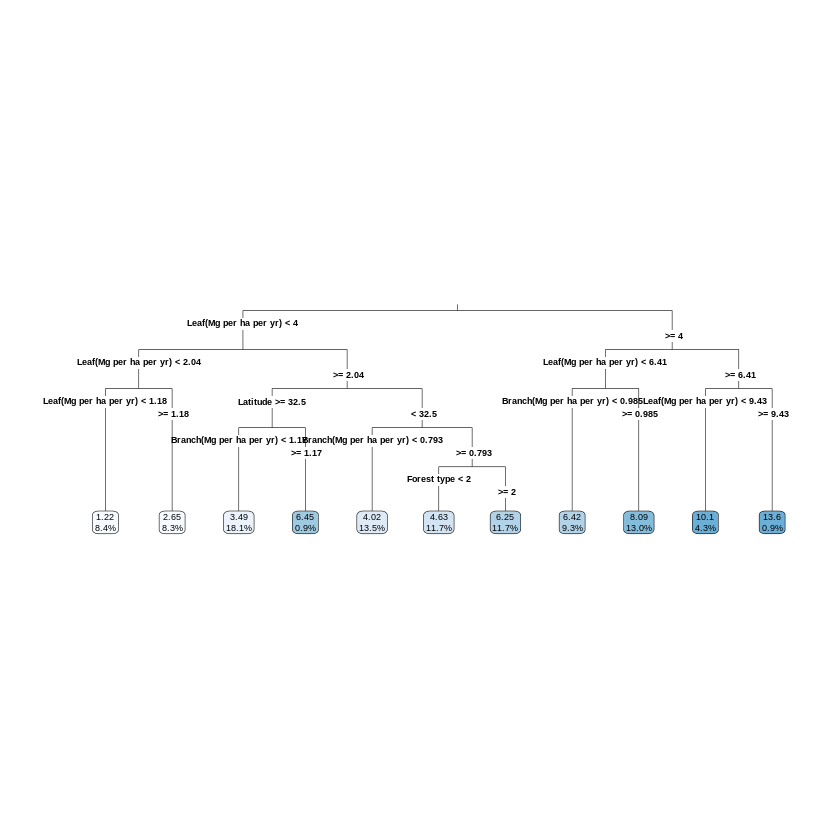

In [ ]:


tuned_tree <- rpart(trainData$`Total(Mg per ha per yr)` ~ ., data = trainData, method = "anova",control = rpart.control(cp = 0.01))
summary(tuned_tree)
rpart.plot(tuned_tree, type = 3, digits = 3, fallen.leaves = TRUE)


In [ ]:
pred(tuned_tree , "Decision tree")

Mean Squared Error (MSE): 1.716347 
Root Mean Squared Error (RMSE): 1.310094 
Mean Absolute Error (MAE): 0.9626417 
R-squared (R^2): 0.7680523 


# **Random Forest**

In [ ]:
# Check column names in trainData and testData to ensure they match
print(colnames(trainData))
print(colnames(testData))

# Rename columns by removing parentheses and extra spaces in both trainData and testData
colnames(trainData) <- gsub("\\(|\\)|\\s", "_", colnames(trainData))
colnames(testData) <- gsub("\\(|\\)|\\s", "_", colnames(testData))  # Apply the same renaming to testData

# Now, train the Random Forest model again
rfModel <- randomForest(Total_Mg_per_ha_per_yr_ ~ ., data = trainData, ntree = 100, mtry = 3, importance = TRUE)

 [1] "site"                                     
 [2] "Latitude"                                 
 [3] "Longitude"                                
 [4] "Altitude(m)"                              
 [5] "MAT"                                      
 [6] "MAP(mm)"                                  
 [7] "Age(year)"                                
 [8] "Density(trees per ha)"                    
 [9] "Leaf(Mg per ha per yr)"                   
[10] "Branch(Mg per ha per yr)"                 
[11] "Reproduction and Others(Mg per ha per yr)"
[12] "Total(Mg per ha per yr)"                  
[13] "Forest type"                              
[14] "Trap size(mm)"                            
[15] "Stand origin"                             
 [1] "site"                                     
 [2] "Latitude"                                 
 [3] "Longitude"                                
 [4] "Altitude(m)"                              
 [5] "MAT"                                      
 [6] "MAP(mm)"      

In [ ]:
pred(rfModel , "Random Forest")

Mean Squared Error (MSE): 0.8956146 
Root Mean Squared Error (RMSE): 0.9463692 
Mean Absolute Error (MAE): 0.647229 
R-squared (R^2): 0.8941425 


In [ ]:

degree <- 2

poly_model <- lm(Total_Mg_per_ha_per_yr_ ~ poly(Latitude, degree) + poly(Altitude_m_, degree) + poly(Age_year_, degree) +
                       poly(Density_trees_per_ha_, degree) + poly(site, degree) + poly(MAT, degree) + poly(MAP_mm_, degree) +
                       poly(Leaf_Mg_per_ha_per_yr_, degree) + poly(Branch_Mg_per_ha_per_yr_, degree) + poly(Reproduction_and_Others_Mg_per_ha_per_yr_, degree) +
                         poly(Forest_type, degree) + poly(Trap_size_mm_, degree) + poly(Stand_origin, degree), data = trainData)

# View model summary
summary(poly_model)

# Make predictions
pred(poly_model, "Polynomial Regression")


Call:
lm(formula = Total_Mg_per_ha_per_yr_ ~ poly(Latitude, degree) + 
    poly(Altitude_m_, degree) + poly(Age_year_, degree) + poly(Density_trees_per_ha_, 
    degree) + poly(site, degree) + poly(MAT, degree) + poly(MAP_mm_, 
    degree) + poly(Leaf_Mg_per_ha_per_yr_, degree) + poly(Branch_Mg_per_ha_per_yr_, 
    degree) + poly(Reproduction_and_Others_Mg_per_ha_per_yr_, 
    degree) + poly(Forest_type, degree) + poly(Trap_size_mm_, 
    degree) + poly(Stand_origin, degree), data = trainData)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.7264 -0.5348 -0.0421  0.5053  6.1835 

Coefficients:
                                                          Estimate Std. Error
(Intercept)                                                5.02801    0.04126
poly(Latitude, degree)1                                    2.23484    7.40394
poly(Latitude, degree)2                                    5.04772    2.26394
poly(Altitude_m_, degree)1                                 3.32625    3.19300
p

Mean Squared Error (MSE): 1.069397 
Root Mean Squared Error (RMSE): 1.034117 
Mean Absolute Error (MAE): 0.7248802 
R-squared (R^2): 0.8566156 
